# 3DGS moderno · Mitad 2 — Entrenamiento con `gsplat`

> ✅ **Validado end-to-end en RTX 5070 (sm_120)** con `torch 2.11.0+cu128` + `gsplat 1.5.3`. Requiere GPU; instalación abajo.

Toma los paquetes que genera el [notebook 03](03-synthetic-views-for-3dgs.ipynb) —vistas RGB + poses + nube inicial— y **entrena** un campo de gaussianas anisótropas optimizándolas contra las vistas (pérdida fotométrica L1).

**Qué cambia con el dataset completo.** El 03 ya no produce 24 vistas de un caso, sino ~**528 por caso sobre decenas de casos**. Eso permite dos cosas que antes no se podían hacer con honestidad:

1. **Vistas retenidas.** Se aparta 1 de cada 8 vistas, el modelo **no las ve nunca**, y se mide el PSNR sobre ellas. Es la diferencia entre «la reconstrucción se parece a lo que le enseñé» (memorizar) y «reconstruye desde ángulos que no vio» (*novel view synthesis*, que es el trabajo real del 3DGS).
2. **Barrido multi-caso** (§6): la misma receta sobre varias anatomías, con su tabla de métricas. Un caso bonito es una anécdota; una tabla es un resultado.

**Pasos:** (0) GPU · (1) cargar paquete y separar vistas retenidas · (2) inicializar gaussianas · (3) entrenar · (4) comparar **en una vista retenida** · (5) exportar + contrato · (6) **barrido multi-caso** · (7) conclusiones · (8) visor interactivo.


## 0 · Verificar GPU + gsplat

In [1]:
import torch
print("torch:", torch.__version__)
assert torch.cuda.is_available(), "sin CUDA — se necesita GPU"
dev = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))
cc = torch.cuda.get_device_capability(0)
print(f"capacidad de cómputo: sm_{cc[0]}{cc[1]}")  # RTX 5070 -> sm_120

import gsplat
from gsplat import rasterization
print("gsplat:", gsplat.__version__)

torch: 2.11.0+cu128
GPU: NVIDIA GeForce RTX 5070
capacidad de cómputo: sm_120
gsplat: 1.5.3


## 1 · Cargar el paquete del notebook 03 y separar las vistas retenidas

El **split**: una de cada `CADA_N` vistas se aparta como *test*. Con la órbita del 03 (azimut × elevación) esas vistas retenidas quedan **repartidas por toda la esfera**, no agrupadas en una zona — así el PSNR de test mide reconstrucción desde ángulos nuevos en general, no la extrapolación a un rincón concreto.

Es el convenio de Nerfstudio/instant-ngp (*holdout* cada 8 vistas), y solo tiene sentido cuando hay vistas de sobra: con pocas vistas, apartar unas cuantas dejaba el entrenamiento cojo y la medida sin precisión. Con 528 no duele: se apartan 66 y quedan 462 para entrenar.


In [2]:
import json
import time
from pathlib import Path

import numpy as np
import vtk
from vtk.util.numpy_support import vtk_to_numpy

# Raiz del repo: se ancla en .git, NO en data/ — el dataset esta gitignored y en
# un clon limpio no existe, asi que como ancla mandaria ROOT a la raiz del sistema.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / ".git").exists():
    ROOT = ROOT.parent
OUT_ROOT = ROOT / "data/processed/teeth3ds"

CADA_N = 8  # 1 de cada 8 vistas se aparta y NO se entrena con ella

PAQUETES = sorted(OUT_ROOT.glob("*_3dgs"))
assert PAQUETES, "No hay paquetes 3dgs — corre antes el notebook 03"
CASE = OUT_ROOT / "01A6GW4A_lower_3dgs"  # caso de referencia (el primero del lote del 03)
if not CASE.exists():
    CASE = PAQUETES[0]
print(f"paquetes disponibles: {len(PAQUETES)} · caso de este notebook: {CASE.name}")


def load_png(path):
    r = vtk.vtkPNGReader(); r.SetFileName(str(path)); r.Update()
    img = r.GetOutput(); dim = img.GetDimensions()
    arr = vtk_to_numpy(img.GetPointData().GetScalars()).reshape(dim[1], dim[0], -1)
    return arr[::-1, :, :3].astype(np.float32) / 255.0  # flip Y, RGB, [0,1]


def cargar_paquete(case_dir):
    """PNG + poses -> tensores en GPU, ya en convencion OpenCV que espera gsplat."""
    meta = json.loads((case_dir / "transforms.json").read_text())
    W, H = meta["w"], meta["h"]
    K = torch.tensor([[meta["fl_x"], 0, meta["cx"]], [0, meta["fl_y"], meta["cy"]], [0, 0, 1]],
                     dtype=torch.float32, device=dev)
    gt = torch.from_numpy(np.stack([load_png(case_dir / f["file_path"]) for f in meta["frames"]])).to(dev)
    c2w = torch.from_numpy(np.stack([np.array(f["transform_matrix"], dtype=np.float32)
                                     for f in meta["frames"]])).to(dev)
    # OpenGL (x der, y arr, z atras) -> OpenCV (x der, y abajo, z delante)
    flip = torch.diag(torch.tensor([1., -1., -1., 1.], device=dev))
    viewmats = torch.linalg.inv(c2w @ flip)                    # world->cam [C,4,4]
    Ks = K.unsqueeze(0).repeat(len(meta["frames"]), 1, 1)      # [C,3,3]
    return gt, viewmats, Ks, W, H


gt, viewmats, Ks, W, H = cargar_paquete(CASE)
n_vistas = gt.shape[0]
IDX_TEST = np.arange(0, n_vistas, CADA_N)                      # las retenidas
IDX_TRAIN = np.setdiff1d(np.arange(n_vistas), IDX_TEST)        # con las que se entrena
print(f"{n_vistas} vistas de {W}x{H} · entrenamiento {len(IDX_TRAIN)} · retenidas {len(IDX_TEST)}"
      f" ({gt.numel() * 4 / 2**20:.0f} MiB en VRAM)")


paquetes disponibles: 20 · caso de este notebook: 01A6GW4A_lower_3dgs


528 vistas de 400x400 · entrenamiento 462 · retenidas 66 (967 MiB en VRAM)


## 2 · Inicializar las gaussianas desde `init.ply`

Cada punto de la nube → una gaussiana. Parámetros optimizables: posición, escala (log), rotación (cuaternión), opacidad (logit) y color (logit RGB).


In [3]:
pr = vtk.vtkPLYReader(); pr.SetFileName(str(CASE / "init.ply")); pr.Update()
init_pts = vtk_to_numpy(pr.GetOutput().GetPoints().GetData()).astype(np.float32)
N = len(init_pts)
means = torch.nn.Parameter(torch.from_numpy(init_pts).to(dev))

extent = float(np.linalg.norm(init_pts.max(0) - init_pts.min(0)))
init_scale = extent * 0.005
scales = torch.nn.Parameter(torch.full((N, 3), np.log(init_scale), device=dev))
quats = torch.nn.Parameter(torch.tensor([1., 0, 0, 0], device=dev).repeat(N, 1))
opacities = torch.nn.Parameter(torch.full((N,), float(np.log(0.1 / 0.9)), device=dev))  # logit(0.1)
colors = torch.nn.Parameter(torch.zeros((N, 3), device=dev))  # sigmoid(0)=0.5 gris

print(f"{N:,} gaussianas · escala inicial {init_scale:.3f} mm")

opt = torch.optim.Adam([
    {"params": [means],     "lr": 1.6e-4 * extent},
    {"params": [scales],    "lr": 5e-3},
    {"params": [quats],     "lr": 1e-3},
    {"params": [opacities], "lr": 5e-2},
    {"params": [colors],    "lr": 2.5e-3},
])


36,664 gaussianas · escala inicial 0.594 mm


## 3 · Bucle de entrenamiento

En cada paso: elegir una vista **del conjunto de entrenamiento**, rasterizar las gaussianas a esa cámara, comparar con la imagen (L1), retropropagar y actualizar. Cada cierto número de pasos se mide el **PSNR en las vistas retenidas** — ángulos que el modelo no ha visto nunca.

Lo que hay que mirar no es que baje la L1 (eso lo consigue cualquier cosa con suficientes parámetros), sino que el **PSNR de test suba con ella**. Si el de train sube y el de test se estanca, el campo está memorizando vistas en vez de reconstruir geometría.

*(Sin densificación en esta versión — se parte de una nube densa; la densificación adaptativa es la mejora natural siguiente.)*


In [4]:
import torch.nn.functional as F


def render_vistas(idx, ms=None, qs=None, sc=None, op=None, co=None):
    """Rasteriza las vistas `idx` con los parametros actuales (o los que se pasen)."""
    ms = means if ms is None else ms
    qs = quats if qs is None else qs
    sc = scales if sc is None else sc
    op = opacities if op is None else op
    co = colors if co is None else co
    out, _, _ = rasterization(
        means=ms, quats=qs / qs.norm(dim=-1, keepdim=True), scales=torch.exp(sc),
        opacities=torch.sigmoid(op), colors=torch.sigmoid(co),
        viewmats=viewmats[idx], Ks=Ks[idx], width=W, height=H,
    )
    return out


def psnr(pred, real):
    return float(-10 * torch.log10(F.mse_loss(pred.clamp(0, 1), real)))


@torch.no_grad()
def evaluar(idx):
    """PSNR medio sobre un conjunto de vistas (de 8 en 8 para no inflar la VRAM)."""
    vals = [psnr(render_vistas(idx[i:i + 8]), gt[idx[i:i + 8]]) for i in range(0, len(idx), 8)]
    return float(np.mean(vals))


ITERS = 9000
historia = []
t0 = time.time()
for it in range(ITERS):
    cam = np.random.choice(IDX_TRAIN)  # SOLO vistas de entrenamiento
    pred = render_vistas([cam])[0]
    loss = F.l1_loss(pred, gt[cam])
    opt.zero_grad(); loss.backward(); opt.step()
    if it % 300 == 0 or it == ITERS - 1:
        p_tr, p_te = evaluar(IDX_TRAIN[:24]), evaluar(IDX_TEST)
        historia.append((it, loss.item(), p_tr, p_te))
        print(f"iter {it:4d} · L1 {loss.item():.4f} · PSNR train {p_tr:5.2f} dB · "
              f"PSNR retenidas {p_te:5.2f} dB")
print(f"\n{ITERS} iteraciones en {time.time() - t0:.0f}s · {N:,} gaussianas")


iter    0 · L1 0.2158 · PSNR train 10.16 dB · PSNR retenidas  9.96 dB


iter  300 · L1 0.0872 · PSNR train 17.58 dB · PSNR retenidas 17.20 dB


iter  600 · L1 0.0522 · PSNR train 19.70 dB · PSNR retenidas 19.53 dB


iter  900 · L1 0.0299 · PSNR train 20.36 dB · PSNR retenidas 20.12 dB


iter 1200 · L1 0.0379 · PSNR train 20.84 dB · PSNR retenidas 20.50 dB


...

iter 7800 · L1 0.0340 · PSNR train 22.87 dB · PSNR retenidas 22.38 dB


iter 8100 · L1 0.0220 · PSNR train 22.80 dB · PSNR retenidas 22.30 dB


iter 8400 · L1 0.0208 · PSNR train 23.38 dB · PSNR retenidas 22.43 dB


iter 8700 · L1 0.0281 · PSNR train 23.70 dB · PSNR retenidas 22.51 dB


iter 8999 · L1 0.0222 · PSNR train 23.42 dB · PSNR retenidas 22.58 dB

9000 iteraciones en 17s · 36,664 gaussianas


Las dos curvas juntas. Que la de vistas retenidas siga a la de entrenamiento —y no se despegue— es la señal de que el campo reconstruye geometría, no memoriza fotos.


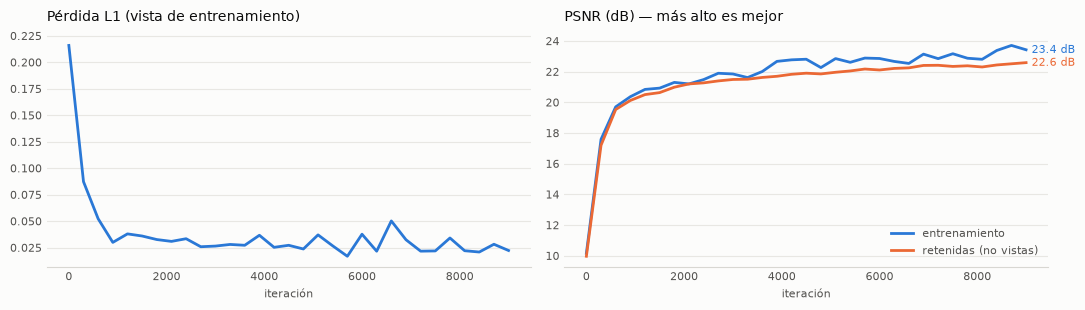

In [5]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, BLUE, NARANJA, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6", "#eb6834", "#e8e7e3"
its = [h[0] for h in historia]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.2), facecolor=SURFACE)
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color("#d8d7d2")
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, length=0, labelsize=8)
    ax.set_xlabel("iteración", color=INK2, fontsize=8)

ax1.plot(its, [h[1] for h in historia], color=BLUE, linewidth=2)
ax1.set_title("Pérdida L1 (vista de entrenamiento)", color=INK, fontsize=10, loc="left", pad=10)

ax2.plot(its, [h[2] for h in historia], color=BLUE, linewidth=2, label="entrenamiento")
ax2.plot(its, [h[3] for h in historia], color=NARANJA, linewidth=2, label="retenidas (no vistas)")
ax2.set_title("PSNR (dB) — más alto es mejor", color=INK, fontsize=10, loc="left", pad=10)
ax2.legend(frameon=False, fontsize=8, labelcolor=INK2)
for y, txt, col in ((historia[-1][2], "train", BLUE), (historia[-1][3], "retenidas", NARANJA)):
    ax2.annotate(f"{y:.1f} dB", (its[-1], y), color=col, fontsize=8,
                 xytext=(4, 0), textcoords="offset points", va="center")

fig.tight_layout()
plt.show()


## 4 · Comparar: 3DGS entrenado vs. vista **retenida**

La comparación honesta: una vista que el modelo **no ha visto durante el entrenamiento**. Si la reconstrucción se parece aquí, el campo ha aprendido la geometría de la arcada, no una colección de fotos.


vista retenida r_0264 (NO usada para entrenar) · PSNR 18.75 dB
izquierda: render de la malla  |  derecha: 3DGS entrenado


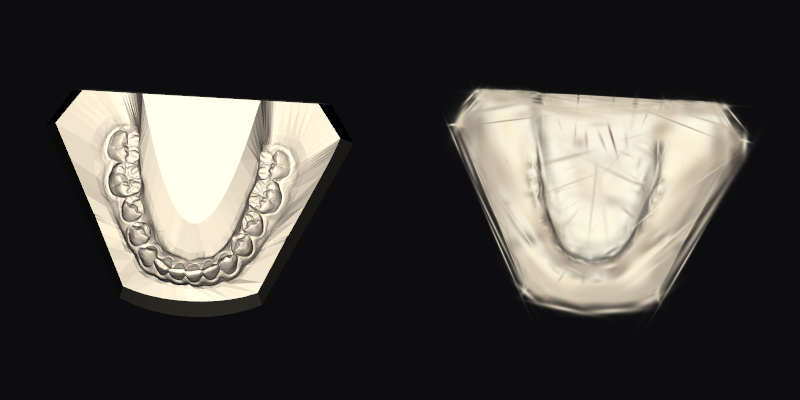

In [6]:
from IPython.display import Image, display

cam = int(IDX_TEST[len(IDX_TEST) // 2])  # una retenida cualquiera, del centro de la orbita
with torch.no_grad():
    pred_t = render_vistas([cam])[0]
p = psnr(pred_t, gt[cam])
pred = (pred_t.clamp(0, 1).cpu().numpy() * 255).astype(np.uint8)
real = (gt[cam].cpu().numpy() * 255).astype(np.uint8)
side = np.concatenate([real, pred], axis=1)  # real | 3DGS

from vtk.util.numpy_support import numpy_to_vtk

img = vtk.vtkImageData(); img.SetDimensions(side.shape[1], side.shape[0], 1)
va = numpy_to_vtk(side[::-1].reshape(-1, 3), deep=True); va.SetNumberOfComponents(3)
img.GetPointData().SetScalars(va)
out = CASE / "compare_real_vs_3dgs.png"
w = vtk.vtkPNGWriter(); w.SetFileName(str(out)); w.SetInputData(img); w.Write()
print(f"vista retenida r_{cam:04d} (NO usada para entrenar) · PSNR {p:.2f} dB")
print("izquierda: render de la malla  |  derecha: 3DGS entrenado")
display(Image(filename=str(out)))


## 5 · Exportar + serializar al contrato

Guardamos el campo entrenado (`.ply`) y lo referenciamos por hash desde un `TwinSnapshot`, igual que el PoC 01 — cierra el círculo con la arquitectura.

In [7]:
import sys, hashlib
from datetime import datetime, timezone

# .ply del campo entrenado (posición + color por gaussiana)
pts_np = means.detach().cpu().numpy()
col_np = (torch.sigmoid(colors).detach().cpu().numpy() * 255).astype(np.uint8)
vpts = vtk.vtkPoints()
for p in pts_np:
    vpts.InsertNextPoint(*p)
pd = vtk.vtkPolyData(); pd.SetPoints(vpts)
carr = numpy_to_vtk(col_np, deep=True); carr.SetName("RGB"); carr.SetNumberOfComponents(3)
pd.GetPointData().SetScalars(carr)
trained = CASE / "trained_3dgs.ply"
w = vtk.vtkPLYWriter(); w.SetFileName(str(trained)); w.SetInputData(pd)
w.SetArrayName("RGB"); w.SetFileTypeToBinary(); w.Write()
digest = hashlib.sha256(trained.read_bytes()).hexdigest()[:16]
print("campo entrenado:", trained.name, "· sha256", digest, "·", len(pts_np), "gaussianas")

sys.path.insert(0, str(ROOT / "packages/core-schemas/src"))
from core_schemas import Modality, Provenance, TwinSnapshot

snap = TwinSnapshot(
    acquisition_id=f"{CASE.name}_trained",
    timestamp=datetime.now(timezone.utc),
    modalities=[Modality.MESH],
    gaussian_field_ref=f"ply://{trained.name}#sha256:{digest}",
    n_primitives=len(pts_np),
    provenance=Provenance(source_file=str(CASE.name), modality=Modality.MESH,
                          agent="gsplat-3dgs-train", confidence=0.5),
)
print(snap.model_dump_json(indent=2))

campo entrenado: trained_3dgs.ply · sha256 3ac19ff214f12651 · 36664 gaussianas
{
  "schema_version": "1.0.0",
  "acquisition_id": "01A6GW4A_lower_3dgs_trained",
  "timestamp": "2026-07-22T17:55:13.190359Z",
  "modalities": [
    "mesh"
  ],
  "ingestion": [],
  "gaussian_field_ref": "ply://trained_3dgs.ply#sha256:3ac19ff214f12651",
  "n_primitives": 36664,
  "regional": [],
  "provenance": {
    "source_file": "01A6GW4A_lower_3dgs",
    "modality": "mesh",
    "agent": "gsplat-3dgs-train",
    "confidence": 0.5,
    "ingested_at": "2026-07-22T17:55:13.190373Z"
  }
}


## 6 · Barrido multi-caso

La misma receta, empaquetada en una función y corrida sobre varios paquetes del lote del 03. Cada caso se entrena desde cero, con su propio *holdout*, y se anota el PSNR en sus vistas retenidas.

Esto es lo que convierte el notebook en evidencia utilizable para decidir el motor de render: no «el 3DGS reconstruyó mi escaneo», sino **qué PSNR da el motor sobre N anatomías distintas y cuánto varía**. La columna de la derecha —la diferencia entre train y retenidas— es la que delata sobreajuste.


In [8]:
CASOS_BARRIDO = 8
ITERS_BARRIDO = 6000


def entrenar_caso(case_dir, iters=ITERS_BARRIDO, seed=0):
    """Receta identica a las §§2-3, compacta, sobre un paquete cualquiera del 03."""
    global gt, viewmats, Ks, W, H, means, quats, scales, opacities, colors
    torch.manual_seed(seed); np.random.seed(seed)
    gt, viewmats, Ks, W, H = cargar_paquete(case_dir)
    n = gt.shape[0]
    idx_test = np.arange(0, n, CADA_N)
    idx_train = np.setdiff1d(np.arange(n), idx_test)

    pr = vtk.vtkPLYReader(); pr.SetFileName(str(case_dir / "init.ply")); pr.Update()
    pts = vtk_to_numpy(pr.GetOutput().GetPoints().GetData()).astype(np.float32)
    n_g = len(pts)
    ext = float(np.linalg.norm(pts.max(0) - pts.min(0)))
    means = torch.nn.Parameter(torch.from_numpy(pts).to(dev))
    scales = torch.nn.Parameter(torch.full((n_g, 3), np.log(ext * 0.005), device=dev))
    quats = torch.nn.Parameter(torch.tensor([1., 0, 0, 0], device=dev).repeat(n_g, 1))
    opacities = torch.nn.Parameter(torch.full((n_g,), float(np.log(0.1 / 0.9)), device=dev))
    colors = torch.nn.Parameter(torch.zeros((n_g, 3), device=dev))
    o = torch.optim.Adam([
        {"params": [means], "lr": 1.6e-4 * ext}, {"params": [scales], "lr": 5e-3},
        {"params": [quats], "lr": 1e-3}, {"params": [opacities], "lr": 5e-2},
        {"params": [colors], "lr": 2.5e-3},
    ])

    t = time.time()
    for _ in range(iters):
        c = np.random.choice(idx_train)
        loss = F.l1_loss(render_vistas([c])[0], gt[c])
        o.zero_grad(); loss.backward(); o.step()
    r = {"caso": case_dir.name.replace("_3dgs", ""), "gauss": n_g, "vistas": n,
         "L1": loss.item(), "psnr_train": evaluar(idx_train[:24]),
         "psnr_test": evaluar(idx_test), "s": time.time() - t}
    torch.cuda.empty_cache()
    return r


lote = [p for p in PAQUETES if p != CASE][:CASOS_BARRIDO - 1]
lote = [CASE] + lote

print(f"{'caso':<20}{'gauss.':>10}{'vistas':>8}{'L1':>8}{'PSNR tr':>9}{'PSNR ret':>10}{'Δ':>7}{'s':>6}")
print("-" * 78)
filas = []
for d in lote:
    r = entrenar_caso(d)
    filas.append(r)
    print(f"{r['caso']:<20}{r['gauss']:>10,}{r['vistas']:>8}{r['L1']:>8.4f}"
          f"{r['psnr_train']:>9.2f}{r['psnr_test']:>10.2f}"
          f"{r['psnr_train'] - r['psnr_test']:>7.2f}{r['s']:>6.0f}")

tr = np.array([f["psnr_train"] for f in filas]); te = np.array([f["psnr_test"] for f in filas])
print("-" * 78)
print(f"{len(filas)} casos · PSNR retenidas {te.mean():.2f} ± {te.std():.2f} dB "
      f"(rango {te.min():.2f}–{te.max():.2f})")
print(f"brecha media train − retenidas: {(tr - te).mean():.2f} dB"
      f"  {'-> sin sobreajuste apreciable' if (tr - te).mean() < 1.5 else '-> revisar sobreajuste'}")


caso                    gauss.  vistas      L1  PSNR tr  PSNR ret      Δ     s
------------------------------------------------------------------------------


01A6GW4A_lower          36,664     528  0.0483    22.70     22.12   0.59    11


014F9HTN_upper          35,788     528  0.0494    23.00     22.25   0.75    11


01AS003D_upper          40,433     528  0.0525    22.97     22.01   0.96    11


01ENPFHF_lower          33,290     528  0.0482    22.62     22.00   0.62    10


01ENPFHF_upper          43,583     528  0.0476    22.89     22.07   0.83    12


01F4RGN8_lower          38,709     528  0.0456    22.69     21.99   0.70    12


01HY2W2Z_upper          43,342     528  0.0517    22.70     21.95   0.75    12


01JZF0KX_lower          35,923     528  0.0485    22.69     22.05   0.65    11
------------------------------------------------------------------------------
8 casos · PSNR retenidas 22.05 ± 0.09 dB (rango 21.95–22.25)
brecha media train − retenidas: 0.73 dB  -> sin sobreajuste apreciable


## 7 · Conclusiones

Este notebook cierra el **3DGS moderno de extremo a extremo**: malla → vistas+poses (03) → **gaussianas entrenadas** (04) → contrato + `.ply`. Con el dataset completo detrás, además:

- **La reconstrucción se mide en vistas que el modelo no vio.** El PSNR de las retenidas (§3, §4) es la métrica defendible; la L1 de entrenamiento sola no distingue reconstruir de memorizar.
- **El resultado es una distribución, no una anécdota** (§6): PSNR medio ± desviación sobre varias anatomías, con la brecha train−retenidas como termómetro de sobreajuste.
- **El coste está medido**: ~5 ms/iteración y <400 MiB de VRAM por caso a 400×400 con ~40 k gaussianas — barato de repetir, lo que hace viable el barrido.

**Límites que siguen en pie:**
- Las vistas son **renders de la malla**, no fotos reales (matiz «circular» documentado en [`docs/research/dataset-teeth3ds.md` §5.1](../docs/research/dataset-teeth3ds.md)). Esto valida el **motor**, no el pipeline foto→3D clínico.
- **Sin densificación ni poda** (`gsplat` `DefaultStrategy`) y **sin armónicos esféricos**: el color es constante por gaussiana, así que el especular del render no se puede reproducir. Ambas son las mejoras naturales siguientes.
- El campo exportado (§5) guarda posición + color; la covarianza anisótropa entrenada **no** viaja en ese `.ply` simple — para un visor web habrá que exportar `.splat`/PLY-3DGS completo.

**Siguiente:** export `.splat` + visor web (three.js / GaussianSplats3D) para inspeccionar el campo entrenado fuera del notebook.


## 8 · Visor interactivo del 3DGS entrenado (ventana nativa)

Como el [notebook 02](02-vtk-interactive-viewer.ipynb): abre una **ventana del
sistema** para **rotar / zoom / pan** el campo de gaussianas entrenado (`trained_3dgs.ply`,
coloreado por el color aprendido de cada gaussiana).

> ⚠️ **Requiere pantalla.** No corre *headless*: abre una **ventana aparte** y la
> celda **se bloquea** hasta que la cierras (tecla `q`). Por eso esta celda va **sin
> salida embebida**. Ejecuta el notebook con `uv run jupyter notebook`. Controles:
> arrastrar (rotar), rueda (zoom), Shift+arrastrar (pan), `q` (cerrar).

In [9]:
import vtk

pr = vtk.vtkPLYReader()
pr.SetFileName(str(CASE / "trained_3dgs.ply"))
pr.Update()

vgf = vtk.vtkVertexGlyphFilter()  # cada gaussiana -> un punto dibujable
vgf.SetInputConnection(pr.GetOutputPort())
vgf.Update()

mapper = vtk.vtkPolyDataMapper()
mapper.SetInputConnection(vgf.GetOutputPort())
mapper.SetColorModeToDirectScalars()  # usar el color RGB aprendido por gaussiana

actor = vtk.vtkActor()
actor.SetMapper(mapper)
actor.GetProperty().SetPointSize(3)

ren = vtk.vtkRenderer(); ren.AddActor(actor); ren.SetBackground(0.05, 0.05, 0.06)
rw = vtk.vtkRenderWindow(); rw.SetSize(900, 700); rw.AddRenderer(ren)
rw.SetWindowName(f"{CASE.name} · 3DGS entrenado")

iren = vtk.vtkRenderWindowInteractor()
iren.SetRenderWindow(rw)
iren.SetInteractorStyle(vtk.vtkInteractorStyleTrackballCamera())

ren.ResetCamera()
rw.Render()
iren.Start()  # cede el control al ratón; bloquea la celda hasta cerrar la ventana